In [252]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import locale
import numpy as np

In [151]:
from math import nan


data = pd.read_csv("./datasets/titanic.csv")

# declaring x and y
x = data.drop(columns=["PassengerId", "Survived", "Name", "Ticket", "Fare", "Cabin", "Embarked"])
y = data["Survived"]

# numerizing data
x["Sex"] = x["Sex"].map({'male': 1, 'female': 0})
x["Age"] = x["Age"].replace({nan: round(x["Age"].mean())})

# variable for future use
dataset_count = len(y)
feature_count = len(x.iloc[0])

# making tensor x and y
x = torch.tensor(x.values, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32)
y = y.unsqueeze(dim=1)

x_max = x.max(dim=0, keepdim=True).values

x = x / x_max

In [88]:
class Classification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(feature_count, feature_count ** 2)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(feature_count ** 2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.sigmoid(x)
        return x
    
model = Classification()
loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-2)

In [89]:
for epoch in range(5000):
    output = model(x)
    
    l = loss(output, y)
    
    l.backward()
    
    optimizer.step()
    optimizer.zero_grad()
    
    print(f"epoch {epoch} = loss: {l}")

epoch 0 = loss: 0.7437863349914551
epoch 1 = loss: 0.6573227643966675
epoch 2 = loss: 0.6226986646652222
epoch 3 = loss: 0.6136083006858826
epoch 4 = loss: 0.6004606485366821
epoch 5 = loss: 0.5774475336074829
epoch 6 = loss: 0.5581124424934387
epoch 7 = loss: 0.5474750995635986
epoch 8 = loss: 0.5368022322654724
epoch 9 = loss: 0.5228068828582764
epoch 10 = loss: 0.5134189128875732
epoch 11 = loss: 0.510486900806427
epoch 12 = loss: 0.5067211389541626
epoch 13 = loss: 0.49937450885772705
epoch 14 = loss: 0.49353623390197754
epoch 15 = loss: 0.49071231484413147
epoch 16 = loss: 0.48574092984199524
epoch 17 = loss: 0.47861337661743164
epoch 18 = loss: 0.474412739276886
epoch 19 = loss: 0.47294652462005615
epoch 20 = loss: 0.47025737166404724
epoch 21 = loss: 0.46719226241111755
epoch 22 = loss: 0.46619585156440735
epoch 23 = loss: 0.464322566986084
epoch 24 = loss: 0.460222989320755
epoch 25 = loss: 0.45709428191185
epoch 26 = loss: 0.4545044004917145
epoch 27 = loss: 0.4508551955223083

In [217]:
pclass = 1
sex = 1
age = 18
sibSp = 0
parch = 0

test_data = torch.tensor([pclass, sex, age, sibSp, parch], dtype=torch.float32) / x_max

alive_prob = int(model(test_data)[0, 0].tolist() * 100)

print(f"survive probability: {alive_prob}%")

survive probability: 15%


i'll try to compare the dataset trend vs the model learned

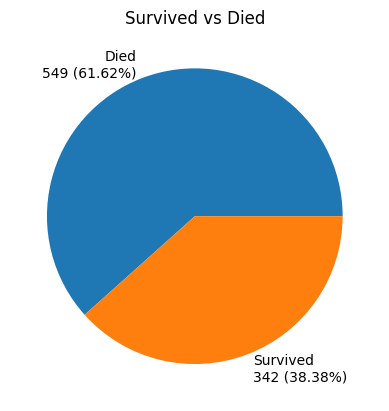

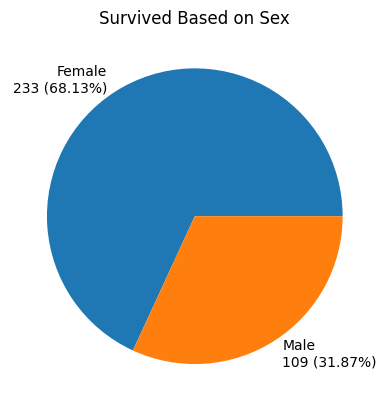

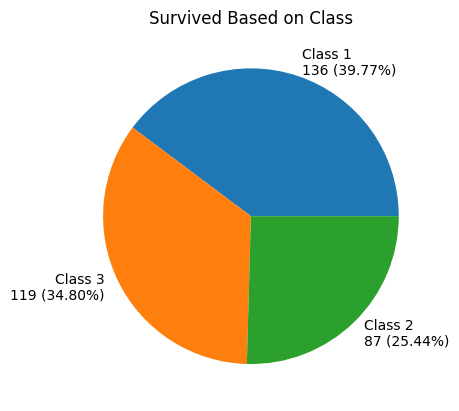

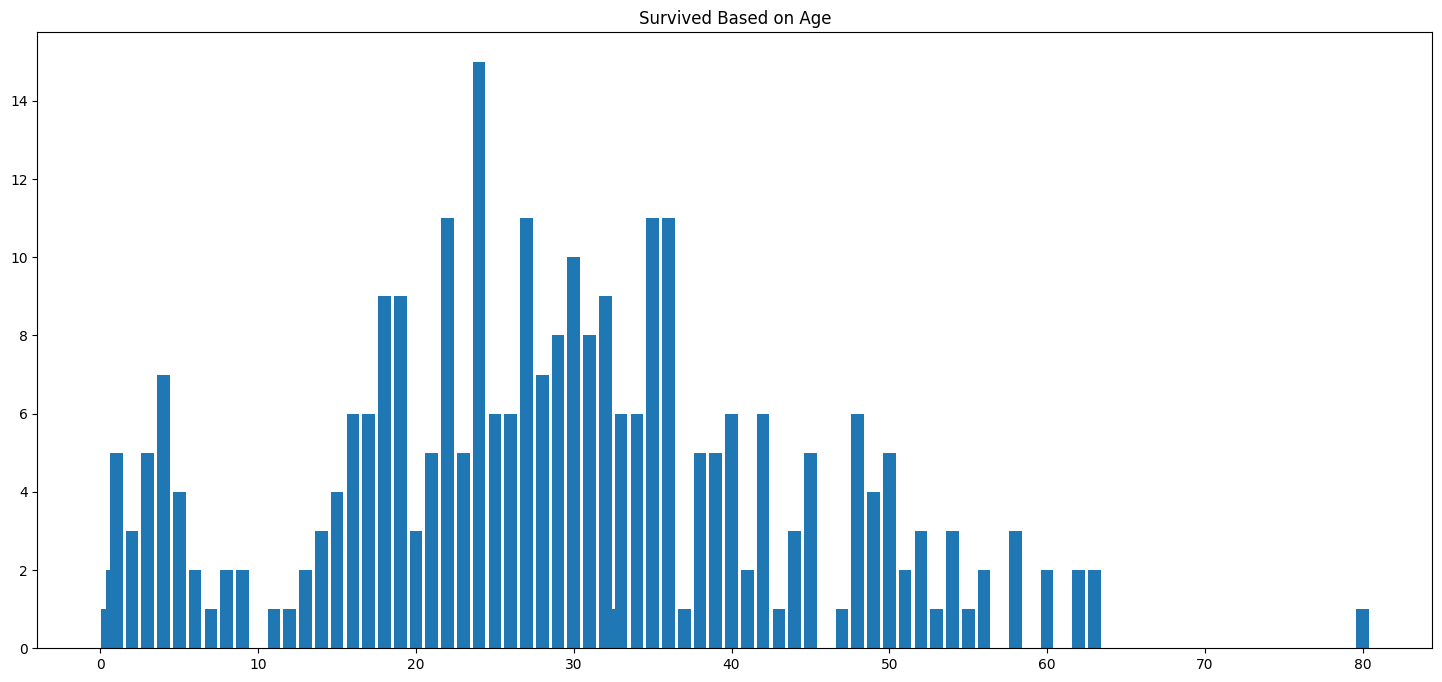

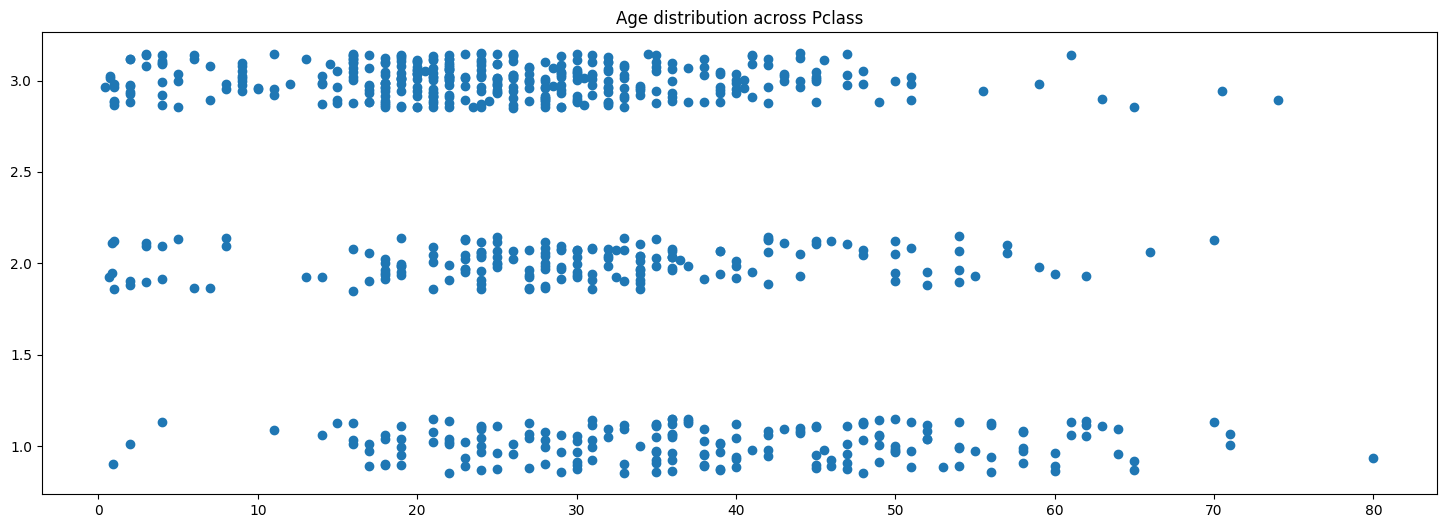

In [257]:
# data trend
def percentage(data, whole_list):
    return f"({(data / sum(whole_list) * 100):.2f}%)"

survived_value_counts = list(data["Survived"].value_counts())
plt.pie(survived_value_counts, labels=[f"Died\n{survived_value_counts[0]} {percentage(survived_value_counts[0], survived_value_counts)}", f"Survived\n{survived_value_counts[1]} {percentage(survived_value_counts[1], survived_value_counts)}"])
plt.title("Survived vs Died")
plt.show()

survived_sex_value_counts = list(((data[data["Survived"] == 1])["Sex"]).value_counts())
plt.pie(survived_sex_value_counts, labels=[f"Female\n{survived_sex_value_counts[0]} {percentage(survived_sex_value_counts[0], survived_sex_value_counts)}", f"Male\n{survived_sex_value_counts[1]} {percentage(survived_sex_value_counts[1], survived_sex_value_counts)}"])
plt.title("Survived Based on Sex")
plt.show()

survived_pclass_value_counts = list(((data[data["Survived"] == 1])["Pclass"]).value_counts())
plt.pie(survived_pclass_value_counts, labels=[f"Class 1\n{survived_pclass_value_counts[0]} {percentage(survived_pclass_value_counts[0], survived_pclass_value_counts)}", f"Class 3\n{survived_pclass_value_counts[1]} {percentage(survived_pclass_value_counts[1], survived_pclass_value_counts)}", f"Class 2\n{survived_pclass_value_counts[2]} {percentage(survived_pclass_value_counts[2], survived_pclass_value_counts)}"])
plt.title("Survived Based on Class")
plt.show()

survived_age_value_counts = ((data[data["Survived"] == 1])["Age"]).value_counts()
plt.figure(figsize=(18, 8))
plt.bar(survived_age_value_counts.index.tolist(), survived_age_value_counts.values.tolist())
plt.title("Survived Based on Age")
plt.show()

plt.figure(figsize=(18, 6))
pclass_list = data["Pclass"].tolist()
age_list = data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise)
plt.title("Age distribution across Pclass")
plt.show()
